https://livelmsip.s3.amazonaws.com/mediaFiles/2023/11/14202240/Module-6-Assignment-1.pdf

Problem Statement:
Fashion MNIST is a dataset of Zalando's article images, consisting of 60,000 training
examples and 10,000 test examples. Each example is a 28x28 grayscale image,
associated with a label from 10 classes. The task is to classify these images into an
apparel category amongst 10 categories on which the dataset is benchmarked.

Objectives:

Data Preparation and Visualization:

● Load the Fashion MNIST dataset.

● Visualize different samples from the dataset.

● Normalize the pixel values of the images to be between 0 and 1 for better
model performance.

● Convert the output labels to categorical format for classification.

Model Building and Training:
Construct a Neural Network using TensorFlow and Keras.

● The model should consist of multiple dense layers with a significant number of neurons.

● Utilize ReLU activation for hidden layers and softmax activation for the output layer.

● Train the model on the prepared dataset.

● Implement callbacks, particularly TensorBoard, to visualize the training process.

Model Evaluation and Analysis:

● Evaluate the model's performance using a validation set.

● Analyze the training process with the help of TensorBoard.

● Save the trained model, including its architecture and learned weights

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.callbacks import TensorBoard
from tensorflow.keras.utils import to_categorical
import datetime

In [3]:
# Load the Fashion MNIST dataset
fashion_mnist = keras.datasets.fashion_mnist
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

print("Training data shape:", x_train.shape)
print("Test data shape:", x_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)


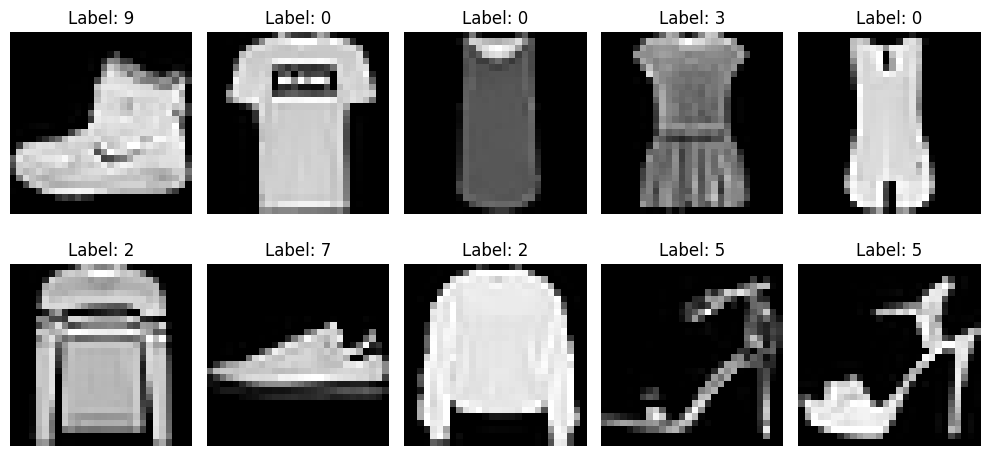

In [4]:
#  Visualize some samples
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [5]:
# Normalize pixel values (0 to 1)
x_train = x_train / 255.0
x_test = x_test / 255.0

In [6]:
# Convert output labels to categorical (one-hot encoding)
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

In [7]:
#  Build the neural network model
model = Sequential()
model.add(Flatten(input_shape=(28, 28)))  # Flatten 28x28 image to 784 vector
model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(10, activation='softmax'))  # Output layer for 10 classes

# Model summary
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Compile the model
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [9]:
# Set up TensorBoard callback
log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)

In [10]:
# Train the model
history = model.fit(
    x_train, y_train_cat,
    epochs=10,
    validation_split=0.2,
    callbacks=[tensorboard_callback]
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.7687 - loss: 0.6670 - val_accuracy: 0.8501 - val_loss: 0.4229
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8595 - loss: 0.3833 - val_accuracy: 0.8550 - val_loss: 0.3936
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8757 - loss: 0.3459 - val_accuracy: 0.8592 - val_loss: 0.3782
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8849 - loss: 0.3112 - val_accuracy: 0.8737 - val_loss: 0.3447
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.8914 - loss: 0.2968 - val_accuracy: 0.8780 - val_loss: 0.3422
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8949 - loss: 0.2835 - val_accuracy: 0.8801 - val_loss: 0.3391
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.8977 - loss: 0.2738 - val_accuracy: 0.8815 - val_loss: 0.3313
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9032 - loss: 0.2566

In [11]:
# Evaluate the model on test data
test_loss, test_acc = model.evaluate(x_test, y_test_cat)
print(f"\nTest accuracy: {test_acc:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8792 - loss: 0.3500

Test accuracy: 0.8800


In [12]:
# Save the model
model.save("fashion_mnist_model.h5")
print("Model saved successfully.")

Model saved successfully.


In [13]:
# Load the saved model
loaded_model = keras.models.load_model("fashion_mnist_model.h5")

In [14]:
# Verify model architecture and parameters
loaded_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,388 (427.30 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)